# Flow Matching, for people who already know diffusion

You know DDPM, DDIM, latent diffusion, VQ-VAEs. So we skip the tourism and go straight to the one idea:

> **Flow matching regresses a velocity vector.** That's it. That's the whole thing.

Everything else — the straight paths, the 10-step sampling, the "it's an ODE" — falls out of that one choice.

### The claim we're going to make, precisely

Flow matching **belongs to the diffusion family**. It is not a rival. Specifically:

| | DDPM | DDIM | **Flow Matching** |
|---|---|---|---|
| forward process | add noise, stochastic | same as DDPM | interpolate, deterministic |
| what the net predicts | $\epsilon$ (noise) | $\epsilon$ (noise) | $v$ (**velocity**) |
| sampler | SDE (stochastic) | **ODE** (deterministic) | **ODE** (deterministic) |
| path shape | circular arc | circular arc | **straight line** |
| steps needed | ~1000 | ~50 | **~10** |

Look at the DDIM column. DDIM is *already* a deterministic ODE. So "FM is the ODE version of diffusion" is **half the story** — DDIM got there first. The thing FM actually changes is the **path**, and that's where the step-count win comes from.

We'll prove all of this in code below, not just assert it.

---
## 1. The setup: two distributions and a straight line between them

Fix notation (⚠️ **this is backwards from DDPM**, so read carefully):

- $x_0 \sim \mathcal{N}(0, I)$ — **noise**
- $x_1 \sim p_{\text{data}}$ — **an anime face**
- $t \in [0,1]$, with $t=0$ noise and $t=1$ data

(DDPM uses $t=0$ for data and $t=T$ for noise. FM papers flip it. Sorry. Blame the literature.)

Now the single design decision that defines flow matching — **connect them with a straight line**:

$$\boxed{x_t = (1-t)\,x_0 + t\,x_1}$$

Differentiate with respect to $t$:

$$\frac{dx_t}{dt} = x_1 - x_0$$

That derivative is a **velocity**. It's constant along the path — it doesn't depend on $t$ at all. It just says *"head from the noise toward the data, in a straight line, at constant speed."*

**The training target is literally that vector.** The network learns:

$$\mathcal{L} = \mathbb{E}_{t, x_0, x_1}\Big[\;\big\|\; v_\theta(x_t, t) - \underbrace{(x_1 - x_0)}_{\text{the velocity}} \;\big\|^2\Big]$$

Compare to DDPM's $\|\epsilon_\theta(x_t,t) - \epsilon\|^2$. **Same shape.** An MSE against a thing you can trivially sample. The only difference is *which* thing.

### Generation = follow the arrows

If you have a velocity field, generation is just solving an ODE:

$$\frac{dx}{dt} = v_\theta(x, t), \qquad x(0) \sim \mathcal{N}(0,I) \;\;\longrightarrow\;\; x(1) = \text{a face}$$

with Euler:  `x = x + v(x, t) * dt`. One line. No noise schedule, no posterior variance, no $\bar\alpha_t$ tables.

In [12]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt, math, time
import os, math, time, glob, shutil, random
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Lambda, RandomHorizontalFlip
import torchvision.utils as vutils
from PIL import Image
from tqdm.auto import tqdm
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0)
print('device:', device)

device: cuda


---
## 2. Why is a *conditional* target allowed? (the one bit of theory)

Here's the objection a good student raises immediately:

> The velocity field we *want* is the **marginal** one: at a given point $x_t$, many different $(x_0, x_1)$ pairs could have produced it. The true field is $v(x_t,t) = \mathbb{E}[x_1 - x_0 \mid x_t]$ — an intractable expectation. But you're regressing on **one sample** $x_1 - x_0$, not the expectation. Isn't that the wrong target?

**No — and this is exactly the trick you already accepted in DDPM.**

When you train DDPM on $\|\epsilon_\theta - \epsilon\|^2$, you're regressing a *single* noise sample, but MSE regression converges to the **conditional mean**. So the net learns $\mathbb{E}[\epsilon \mid x_t]$, which is what you wanted. Same thing here: regressing the *conditional* velocity $x_1 - x_0$ yields the *marginal* field $\mathbb{E}[x_1-x_0 \mid x_t]$ for free.

This is the whole content of the Flow Matching theorem (Lipman et al. 2022). Let's verify it numerically instead of taking it on faith.

In [2]:
# Toy check: noise x0 ~ N(0,I) -> target = a single point 'a'.
# For this case the MARGINAL velocity has a closed form, so we can compare.
torch.manual_seed(0)
a = torch.tensor([2.0, -1.0])
t = 0.3
N = 400_000

x0 = torch.randn(N, 2)
x1 = a.expand(N, 2)
xt = (1 - t) * x0 + t * x1
u  = x1 - x0                      # the CONDITIONAL target we actually regress

# Analytic marginal: given xt and t, x1 = a and x0 = (xt - t*a)/(1-t), so
#   v(xt,t) = a - (xt - t*a)/(1-t)
probe = torch.tensor([[0.5, 0.2]])
v_analytic = (a - (probe - t * a) / (1 - t)).squeeze()

# Empirical E[u | xt ~ probe]
mask = (xt - probe).norm(dim=1) < 0.02
v_empirical = u[mask].mean(0)

print(f'samples near probe        : {mask.sum().item()}')
print(f'analytic marginal velocity: {[round(x,4) for x in v_analytic.tolist()]}')
print(f'empirical E[x1-x0 | xt]   : {[round(x,4) for x in v_empirical.tolist()]}')
print(f'max diff                  : {(v_analytic - v_empirical).abs().max():.4f}')
print('\nRegressing the CONDITIONAL target recovers the MARGINAL field.')
print('Same trick as predicting eps in DDPM. This is why FM is trainable at all.')

samples near probe        : 120
analytic marginal velocity: [2.1429, -1.7143]
empirical E[x1-x0 | xt]   : [2.1409, -1.7143]
max diff                  : 0.0020

Regressing the CONDITIONAL target recovers the MARGINAL field.
Same trick as predicting eps in DDPM. This is why FM is trainable at all.


---
## 3. "FM is just diffusion" — let's actually prove it

Every method in this family builds $x_t$ as **signal coefficient × data + noise coefficient × noise**:

$$x_t = a(t)\,x_1 + b(t)\,\epsilon$$

| method | $a(t)$ | $b(t)$ | constraint |
|---|---|---|---|
| **Flow matching** | $t$ | $1-t$ | $a + b = 1$ → **a straight line** |
| **DDPM / VP** | $\sqrt{\bar\alpha_t}$ | $\sqrt{1-\bar\alpha_t}$ | $a^2 + b^2 = 1$ → **a circular arc** |

They differ **only in the curve** they trace through coefficient space. And given any such path, the velocity $v$ and the noise $\epsilon$ carry **exactly the same information** — you can convert one into the other with 2×2 linear algebra.

In [3]:
# v-prediction and eps-prediction are linear reparameterizations of each other.
torch.manual_seed(0)
B = 1000
x1  = torch.randn(B, 3)
eps = torch.randn(B, 3)

print('recovering (eps, x1) from (xt, v) exactly:')
for t in [0.1, 0.5, 0.9]:
    a, b   = t, 1 - t          # FM path coefficients
    ap, bp = 1.0, -1.0         # their derivatives da/dt, db/dt
    xt = a * x1 + b * eps
    v  = ap * x1 + bp * eps    # = x1 - eps : the FM target

    det     = a * bp - b * ap
    eps_rec = (a * v - ap * xt) / det
    x1_rec  = (bp * xt - b * v) / det
    print(f'  t={t}:  |eps - eps_rec| = {(eps-eps_rec).abs().max():.2e}   '
          f'|x1 - x1_rec| = {(x1-x1_rec).abs().max():.2e}')

print('\nExact to float precision. v and eps are the SAME INFORMATION.')
print('FM is not a new family -- it is a different regression target on the same object.')

recovering (eps, x1) from (xt, v) exactly:
  t=0.1:  |eps - eps_rec| = 2.38e-07   |x1 - x1_rec| = 4.77e-07
  t=0.5:  |eps - eps_rec| = 2.38e-07   |x1 - x1_rec| = 2.38e-07
  t=0.9:  |eps - eps_rec| = 4.77e-07   |x1 - x1_rec| = 2.38e-07

Exact to float precision. v and eps are the SAME INFORMATION.
FM is not a new family -- it is a different regression target on the same object.


### So where does the actual advantage come from?

Not from the objective. **From the geometry of the path.**

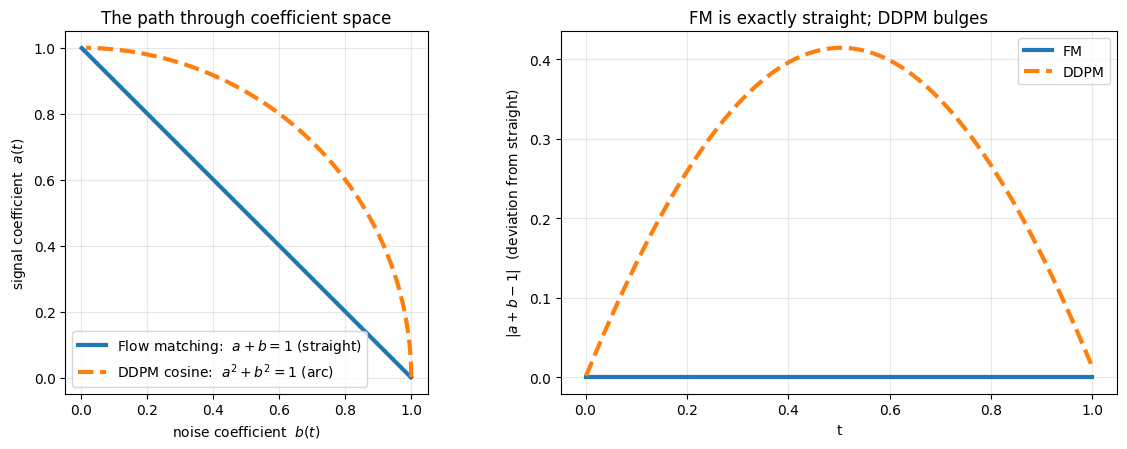

mean |a+b-1|   FM: 0.000000   DDPM: 0.2750
A straight path  =>  velocity is nearly constant along a trajectory
                 =>  a big Euler step does not overshoot
                 =>  10 steps is enough.

THAT is the few-step story. Not a better loss -- a straighter road.


In [4]:
ts = torch.linspace(0.001, 0.999, 300)

# FM: straight line, a + b = 1
a_fm, b_fm = ts, 1 - ts

# DDPM cosine schedule: a^2 + b^2 = 1 (a circular arc)
s = 0.008
ab = torch.cos(((1 - ts) + s) / (1 + s) * math.pi / 2) ** 2
a_dd, b_dd = ab.sqrt(), (1 - ab).sqrt()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].plot(b_fm, a_fm, lw=3, label='Flow matching:  $a+b=1$ (straight)')
ax[0].plot(b_dd, a_dd, lw=3, ls='--', label='DDPM cosine:  $a^2+b^2=1$ (arc)')
ax[0].set_xlabel('noise coefficient  $b(t)$'); ax[0].set_ylabel('signal coefficient  $a(t)$')
ax[0].set_title('The path through coefficient space'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[0].set_aspect('equal')

ax[1].plot(ts, (a_fm + b_fm - 1).abs(), lw=3, label='FM')
ax[1].plot(ts, (a_dd + b_dd - 1).abs(), lw=3, ls='--', label='DDPM')
ax[1].set_xlabel('t'); ax[1].set_ylabel('$|a+b-1|$  (deviation from straight)')
ax[1].set_title('FM is exactly straight; DDPM bulges'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'mean |a+b-1|   FM: {(a_fm+b_fm-1).abs().mean():.6f}   DDPM: {(a_dd+b_dd-1).abs().mean():.4f}')
print("A straight path  =>  velocity is nearly constant along a trajectory")
print("                 =>  a big Euler step does not overshoot")
print("                 =>  10 steps is enough.")
print("")
print("THAT is the few-step story. Not a better loss -- a straighter road.")

---
## 4. Watch it work in 2-D before we touch images

Full FM in ~15 lines. Train, then sample with different step counts and see where quality saturates.

In [5]:
def two_moons(n):
    th = torch.rand(n) * math.pi
    x = torch.stack([th.cos(), th.sin()], 1) * 2
    x[n//2:, 1] *= -1
    x[n//2:, 0] += 1
    return x + torch.randn(n, 2) * 0.1

toy = nn.Sequential(nn.Linear(3,128), nn.SiLU(),
                    nn.Linear(128,128), nn.SiLU(),
                    nn.Linear(128,2)).to(device)
opt = torch.optim.Adam(toy.parameters(), lr=2e-3)

for i in range(3000):
    x1 = two_moons(512).to(device)          # data
    x0 = torch.randn(512, 2, device=device) # noise
    t  = torch.rand(512, 1, device=device)

    xt       = (1 - t) * x0 + t * x1        # interpolate
    v_target = x1 - x0                      # <-- THE VELOCITY. that's the target.
    v_pred   = toy(torch.cat([xt, t], 1))

    loss = ((v_pred - v_target) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()

print(f'final loss: {loss.item():.4f}')
print("NOTE: this loss plateaus and does NOT go to zero. That is correct.")
print("Given xt, the target x1-x0 is genuinely random (many pairs make the same xt).")
print("The net learns its conditional MEAN; the leftover variance is irreducible.")
print("Same reason your DDPM eps-loss never hits zero.")

final loss: 2.2202
NOTE: this loss plateaus and does NOT go to zero. That is correct.
Given xt, the target x1-x0 is genuinely random (many pairs make the same xt).
The net learns its conditional MEAN; the leftover variance is irreducible.
Same reason your DDPM eps-loss never hits zero.


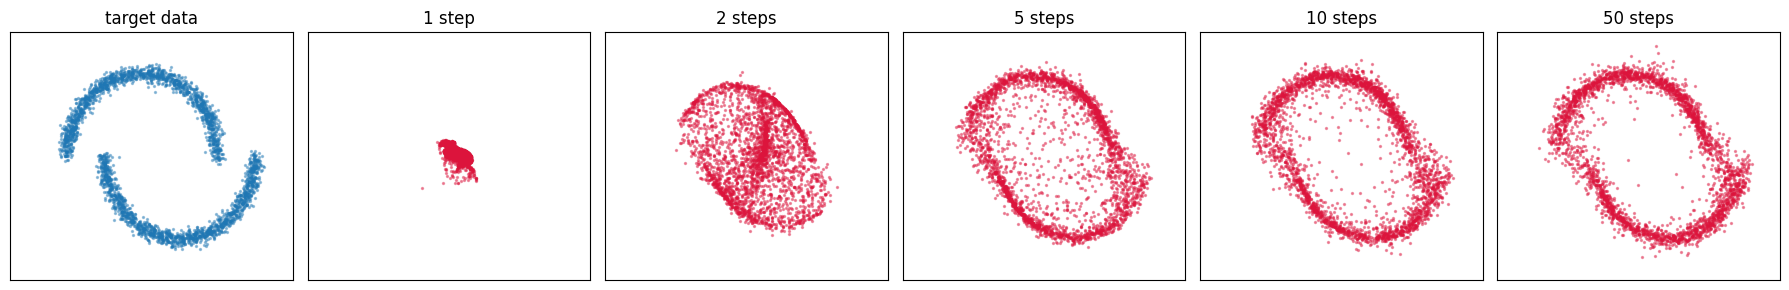

In [6]:
@torch.no_grad()
def toy_sample(n, steps):
    # Euler ODE solve: x <- x + v(x,t)*dt. This is the entire sampler.
    x = torch.randn(n, 2, device=device)
    dt = 1.0 / steps
    traj = [x.cpu().numpy()]
    for i in range(steps):
        t = torch.full((n, 1), i * dt, device=device)
        x = x + toy(torch.cat([x, t], 1)) * dt
        traj.append(x.cpu().numpy())
    return x, traj

real = two_moons(3000).numpy()
step_list = [1, 2, 5, 10, 50]
fig, axes = plt.subplots(1, len(step_list)+1, figsize=(3*(len(step_list)+1), 3))
axes[0].scatter(real[:,0], real[:,1], s=2, alpha=.4); axes[0].set_title('target data')
for ax, steps in zip(axes[1:], step_list):
    s, _ = toy_sample(3000, steps)
    s = s.cpu().numpy()
    ax.scatter(s[:,0], s[:,1], s=2, alpha=.4, color='crimson')
    ax.set_title(f'{steps} step' + ('s' if steps>1 else ''))
for ax in axes: ax.set_xlim(-3.5,4); ax.set_ylim(-3,3); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

In [7]:
# Where does it saturate? (moment mismatch -- crude but honest)
real_t = two_moons(4000).to(device)
print('steps   moment mismatch vs data')
for steps in [1, 2, 5, 10, 20, 50, 200]:
    s, _ = toy_sample(4000, steps)
    d = (s.mean(0)-real_t.mean(0)).norm().item() + (s.std(0)-real_t.std(0)).norm().item()
    print(f'{steps:5d}   {d:.4f}')
print("1-2 steps: bad. 5: decent. 10: basically converged. 50+: no further gain.")
print("Note it does NOT work at 1 step. FM is not magic. Anyone claiming")
print("'flow matching = one-step generation' means rectified-flow REFLOW or")
print("DISTILLATION, which are extra procedures layered on top of this.")

steps   moment mismatch vs data
    1   1.8881
    2   0.9173
    5   0.3065
   10   0.2244
   20   0.1286
   50   0.1334
  200   0.1065
1-2 steps: bad. 5: decent. 10: basically converged. 50+: no further gain.
Note it does NOT work at 1 step. FM is not magic. Anyone claiming
'flow matching = one-step generation' means rectified-flow REFLOW or
DISTILLATION, which are extra procedures layered on top of this.


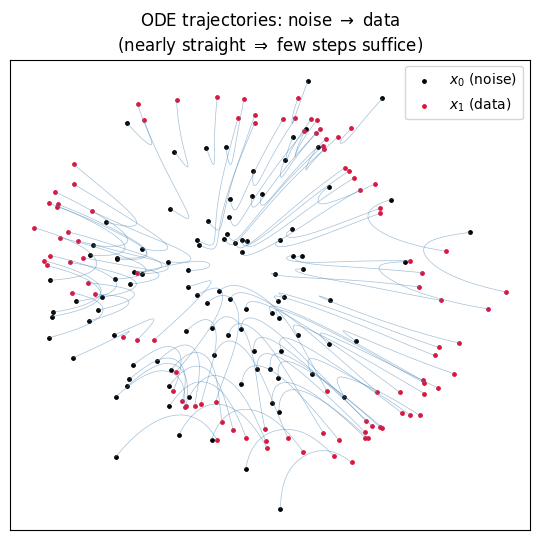

In [8]:
# The trajectories are visibly near-straight -- that's the whole point.
_, traj = toy_sample(300, 50)
traj = np.stack(traj)                       # [steps+1, n, 2]
plt.figure(figsize=(5.5, 5.5))
for i in range(0, 300, 3):
    plt.plot(traj[:, i, 0], traj[:, i, 1], lw=.5, alpha=.5, color='steelblue')
plt.scatter(traj[0, ::3, 0],  traj[0, ::3, 1],  s=6, color='k',       label='$x_0$ (noise)')
plt.scatter(traj[-1, ::3, 0], traj[-1, ::3, 1], s=6, color='crimson', label='$x_1$ (data)')
plt.legend(); plt.title('ODE trajectories: noise $\\to$ data\n(nearly straight $\\Rightarrow$ few steps suffice)')
plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

---
## 5. Now the real thing: anime faces at 64×64

Same five lines of math, bigger network.

### Why pixels and not a VQ latent?

You know latent diffusion, so the obvious question is why we are not encoding first. At 64x64 we do not need to: 3×64×64 is small enough to train directly on Colab, and working in pixels keeps the velocity field *visible as an image* — which is the point of the lesson.

**If you did want latent FM, the change is exactly two lines** and nothing else:

```python
x1 = vae.encode(images).latents        # instead of x1 = images
...                                    # identical training loop
imgs = vae.decode(x1_generated)        # instead of using x1 directly
```

That's it. FM does not care what space it's in — it interpolates between two points and regresses the difference. The VQ-f4 encoder from `CompVis/ldm-celebahq-256` would give you 3×16×16 latents (4× downsample), ~16× fewer dims. Worth it at 256×256; unnecessary at 64.

In [9]:
class SinusoidalTime(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        f = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        a = t[:, None] * f[None] * 1000.0
        return torch.cat([a.sin(), a.cos()], -1)

class Block(nn.Module):
    def __init__(self, cin, cout, tdim):
        super().__init__()
        self.n1 = nn.GroupNorm(8, cin);  self.c1 = nn.Conv2d(cin, cout, 3, 1, 1)
        self.emb = nn.Linear(tdim, cout)
        self.n2 = nn.GroupNorm(8, cout); self.c2 = nn.Conv2d(cout, cout, 3, 1, 1)
        self.skip = nn.Conv2d(cin, cout, 1) if cin != cout else nn.Identity()
    def forward(self, x, t):
        h = self.c1(F.silu(self.n1(x)))
        h = h + self.emb(F.silu(t))[:, :, None, None]
        h = self.c2(F.silu(self.n2(h)))
        return h + self.skip(x)

class Attn(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.n = nn.GroupNorm(8, c); self.qkv = nn.Conv2d(c, c*3, 1); self.o = nn.Conv2d(c, c, 1)
    def forward(self, x):
        B, C, H, W = x.shape
        q, k, v = self.qkv(self.n(x)).reshape(B, 3, C, H*W).permute(1, 0, 3, 2)
        h = F.scaled_dot_product_attention(q, k, v)
        return x + self.o(h.permute(0, 2, 1).reshape(B, C, H, W))

class UNet(nn.Module):
    # Small UNet. Input (x, t) -> output same shape as x.
    # NOTE: identical net used for FM and DDPM below -> controlled comparison.
    def __init__(self, ch=64, mults=(1, 2, 2, 4), attn_res=(16,), in_ch=3, img=64):
        super().__init__()
        tdim = ch * 4
        self.time = nn.Sequential(SinusoidalTime(ch), nn.Linear(ch, tdim), nn.SiLU(), nn.Linear(tdim, tdim))
        self.cin = nn.Conv2d(in_ch, ch, 3, 1, 1)
        chans = [ch]; cur = ch
        self.downs = nn.ModuleList()
        for i, m in enumerate(mults):
            out = ch * m
            for _ in range(2):
                self.downs.append(nn.ModuleList([Block(cur, out, tdim),
                                                 Attn(out) if (img >> i) in attn_res else nn.Identity()]))
                cur = out; chans.append(cur)
            if i < len(mults) - 1:
                self.downs.append(nn.ModuleList([nn.Conv2d(cur, cur, 3, 2, 1), nn.Identity()]))
                chans.append(cur)
        self.mid1 = Block(cur, cur, tdim); self.mida = Attn(cur); self.mid2 = Block(cur, cur, tdim)
        self.ups = nn.ModuleList()
        for i, m in reversed(list(enumerate(mults))):
            out = ch * m
            for _ in range(3):
                self.ups.append(nn.ModuleList([Block(cur + chans.pop(), out, tdim),
                                               Attn(out) if (img >> i) in attn_res else nn.Identity()]))
                cur = out
            if i > 0:
                self.ups.append(nn.ModuleList([nn.Upsample(scale_factor=2, mode='nearest'), nn.Identity()]))
        self.out = nn.Sequential(nn.GroupNorm(8, cur), nn.SiLU(), nn.Conv2d(cur, in_ch, 3, 1, 1))
        nn.init.zeros_(self.out[-1].weight); nn.init.zeros_(self.out[-1].bias)

    def forward(self, x, t):
        temb = self.time(t)
        h = self.cin(x); hs = [h]
        for m, a in self.downs:
            if isinstance(m, Block):
                h = m(h, temb)
                if not isinstance(a, nn.Identity): h = a(h)
            else:
                h = m(h)
            hs.append(h)
        h = self.mid1(h, temb); h = self.mida(h); h = self.mid2(h, temb)
        for m, a in self.ups:
            if isinstance(m, Block):
                h = torch.cat([h, hs.pop()], 1)
                h = m(h, temb)
                if not isinstance(a, nn.Identity): h = a(h)
            else:
                h = m(h)
        return self.out(h)

_m = UNet().to(device)
print(f'UNet params: {sum(p.numel() for p in _m.parameters())/1e6:.1f}M')
del _m

UNet params: 16.3M


### The training step — read this and you've read the whole method

```python
x1 = batch                                  # data
x0 = torch.randn_like(x1)                   # noise
t  = torch.rand(B)                          # uniform time

xt = (1-t)*x0 + t*x1                        # interpolate  (linear! no schedule table)
v_target = x1 - x0                          # the velocity  (constant along the path)

loss = mse(net(xt, t), v_target)            # regress it
```

Now compare to your DDPM step:

```python
t  = torch.randint(0, T, (B,))
eps = torch.randn_like(x0)
xt = sqrt_ab[t]*x0 + sqrt_1mab[t]*eps       # interpolate  (needs the alpha_bar table)
loss = mse(net(xt, t), eps)                 # regress the noise
```

**Structurally identical.** Two differences: FM's coefficients are just $t$ and $1-t$ (no schedule to tune), and the target is $x_1 - x_0$ instead of $\epsilon$. That's the entire delta.

In [10]:
def fm_loss(net, x1):
    # Flow matching loss. This function is the whole method.
    B = x1.shape[0]
    x0 = torch.randn_like(x1)                                   # noise
    t  = torch.rand(B, device=x1.device)                        # t ~ U[0,1]
    t_ = t.view(B, 1, 1, 1)

    xt       = (1 - t_) * x0 + t_ * x1                          # straight-line interpolation
    v_target = x1 - x0                                          # <-- THE VELOCITY
    v_pred   = net(xt, t)
    return F.mse_loss(v_pred, v_target)


@torch.no_grad()
def fm_sample(net, n=16, steps=10, size=64, ch=3, return_traj=False):
    # Euler ODE integration from t=0 (noise) to t=1 (data).
    net.eval()
    x = torch.randn(n, ch, size, size, device=device)
    dt = 1.0 / steps
    traj = [x.cpu()]
    for i in range(steps):
        t = torch.full((n,), i * dt, device=device)
        x = x + net(x, t) * dt                                  # <-- the entire sampler
        if return_traj: traj.append(x.cpu())
    net.train()
    return (x, traj) if return_traj else x

print('fm_loss + fm_sample defined. Note the sampler is 4 lines and has no schedule.')

fm_loss + fm_sample defined. Note the sampler is 4 lines and has no schedule.


### Data

In [14]:
#@title download dataset
import kagglehub
from IPython.display import clear_output
path = kagglehub.dataset_download("soumikrakshit/anime-faces")
dataset_path = os.path.join(path, "data")
clear_output()
print("dataset:", dataset_path)

dataset: /kaggle/input/anime-faces/data


In [15]:
#@title dataset + dataloaders
IMAGE_SIZE   = 64
BATCH_SIZE   = 64
VAL_FRACTION = 0.05

transform = Compose([
    Resize(IMAGE_SIZE),
    CenterCrop(IMAGE_SIZE),
    RandomHorizontalFlip(p=0.5),      # free augmentation for faces
    ToTensor(),                       # -> [0, 1]
    Lambda(lambda t: t * 2 - 1),      # -> [-1, 1]
])

class AnimeFaces(Dataset):
    def __init__(self, root, transform):
        self.root, self.transform = root, transform
        self.files = [f for f in os.listdir(root)
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))]
    def __len__(self):  return len(self.files)
    def __getitem__(self, i):
        img = Image.open(os.path.join(self.root, self.files[i])).convert("RGB")
        return self.transform(img), 0

full = AnimeFaces(dataset_path, transform)
val_n   = int(len(full) * VAL_FRACTION)
train_n = len(full) - val_n
g = torch.Generator().manual_seed(42)
train_set, val_set = torch.utils.data.random_split(full, [train_n, val_n], generator=g)

workers = min(4, os.cpu_count() or 2)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=workers, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=workers, pin_memory=True)

print(f"train {train_n:,} | val {val_n:,} | batches/epoch {len(train_loader)}")

train 20,474 | val 1,077 | batches/epoch 319


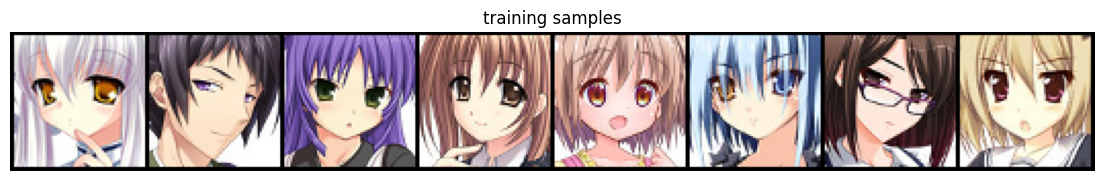

In [16]:
#@title peek at the data
imgs = torch.stack([train_set[i][0] for i in range(8)])
grid = vutils.make_grid((imgs + 1) / 2, nrow=8, padding=2)
plt.figure(figsize=(14, 2)); plt.axis("off")
plt.imshow(grid.permute(1, 2, 0).numpy()); plt.title("training samples"); plt.show()

---
## 6. Train it

**This is the cell you run.** ~30-60 min on a Colab T4 for decent faces; longer is better. `fm_loss` is the only thing that makes this flow matching — swap it for a DDPM loss and the same UNet becomes a DDPM.

Expect the loss to plateau (around ~0.5-1.0 here) rather than crawl to zero — see the note in §4.

epoch   1/30  fm loss 0.5003   (85s)
epoch   2/30  fm loss 0.2810   (167s)
epoch   3/30  fm loss 0.2565   (249s)
epoch   4/30  fm loss 0.2453   (332s)
epoch   5/30  fm loss 0.2386   (414s)
epoch   6/30  fm loss 0.2331   (497s)
epoch   7/30  fm loss 0.2293   (579s)
epoch   8/30  fm loss 0.2258   (661s)
epoch   9/30  fm loss 0.2250   (744s)
epoch  10/30  fm loss 0.2225   (826s)
epoch  11/30  fm loss 0.2218   (909s)
epoch  12/30  fm loss 0.2191   (991s)
epoch  13/30  fm loss 0.2182   (1074s)
epoch  14/30  fm loss 0.2179   (1156s)
epoch  15/30  fm loss 0.2168   (1238s)
epoch  16/30  fm loss 0.2150   (1321s)
epoch  17/30  fm loss 0.2150   (1403s)
epoch  18/30  fm loss 0.2122   (1486s)
epoch  19/30  fm loss 0.2127   (1568s)
epoch  20/30  fm loss 0.2119   (1651s)
epoch  21/30  fm loss 0.2119   (1733s)
epoch  22/30  fm loss 0.2100   (1816s)
epoch  23/30  fm loss 0.2109   (1898s)
epoch  24/30  fm loss 0.2080   (1981s)
epoch  25/30  fm loss 0.2094   (2063s)
epoch  26/30  fm loss 0.2083   (2146s)

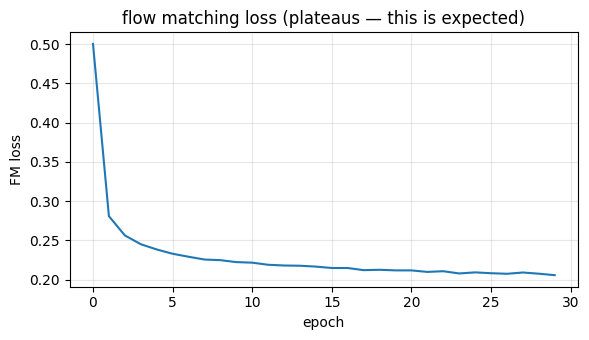

In [17]:
EPOCHS = 30          # bump this up if you have time; faces keep improving
LR     = 2e-4

net = UNet(ch=64).to(device)
opt = torch.optim.AdamW(net.parameters(), lr=LR, weight_decay=0.0)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

# EMA -- matters a lot for sample quality, same as your diffusion runs
ema = UNet(ch=64).to(device); ema.load_state_dict(net.state_dict())
ema.requires_grad_(False)

@torch.no_grad()
def ema_update(decay=0.999):
    for pe, pn in zip(ema.parameters(), net.parameters()):
        pe.mul_(decay).add_(pn, alpha=1-decay)
    for be, bn in zip(ema.buffers(), net.buffers()):
        be.copy_(bn)

losses = []
t0 = time.time()
for ep in range(EPOCHS):
    run = n = 0
    for x1, _ in train_loader:
        x1 = x1.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            loss = fm_loss(net, x1)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update()
        ema_update()
        run += loss.item() * x1.size(0); n += x1.size(0)
    losses.append(run / n)
    print(f'epoch {ep+1:3d}/{EPOCHS}  fm loss {run/n:.4f}   ({time.time()-t0:.0f}s)', flush=True)

plt.figure(figsize=(6,3.5))
plt.plot(losses); plt.xlabel('epoch'); plt.ylabel('FM loss'); plt.grid(alpha=.3)
plt.title('flow matching loss (plateaus — this is expected)'); plt.tight_layout(); plt.show()

---
## 7. The payoff: how few steps can we get away with?

**Same model, same noise seed, only the step count changes.**

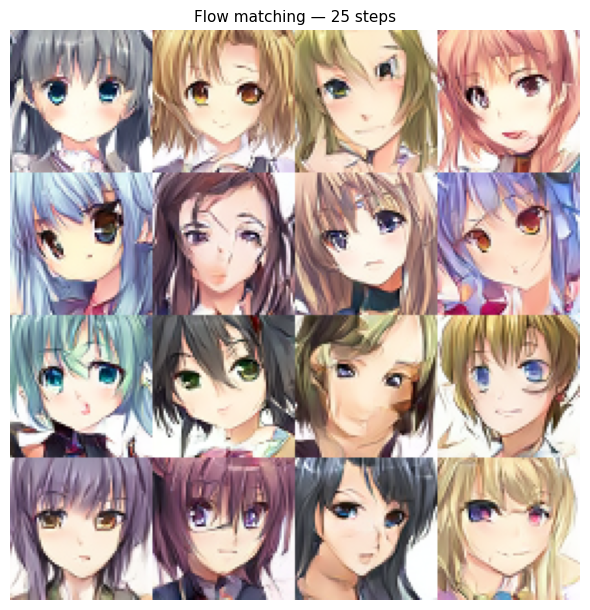

In [30]:
#@title choose n and s
def show(imgs, title, ax):
    g = ((imgs.clamp(-1, 1) + 1) / 2).cpu()
    n = int(math.sqrt(g.shape[0]))
    grid = g[:n*n].reshape(n, n, 3, 64, 64).permute(0, 3, 1, 4, 2).reshape(n*64, n*64, 3).numpy()
    ax.imshow(grid); ax.axis('off'); ax.set_title(title, fontsize=11)

STEPS = 25          # <-- pick any number of Euler steps
N = 16              # <-- number of samples (should be a perfect square)

torch.manual_seed(7)
imgs = fm_sample(ema, n=N, steps=STEPS)

fig, ax = plt.subplots(figsize=(6, 6.4))
show(imgs, f'Flow matching — {STEPS} step' + ('s' if STEPS > 1 else ''), ax)
plt.tight_layout(); plt.show()

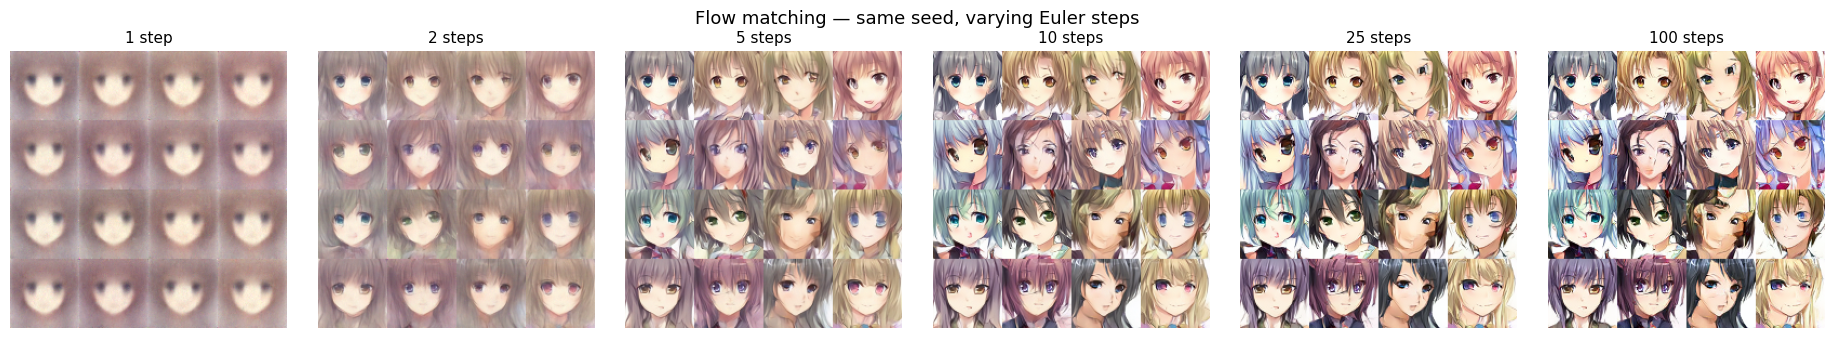

In [18]:
def show(imgs, title):
    g = ((imgs.clamp(-1,1) + 1) / 2).cpu()
    n = int(math.sqrt(g.shape[0]))
    grid = g[:n*n].reshape(n, n, 3, 64, 64).permute(0, 3, 1, 4, 2).reshape(n*64, n*64, 3).numpy()
    plt.imshow(grid); plt.axis('off'); plt.title(title, fontsize=11)

STEPS = [1, 2, 5, 10, 25, 100]
plt.figure(figsize=(3.1*len(STEPS), 3.4))
for i, s in enumerate(STEPS):
    torch.manual_seed(7)                      # same starting noise every time
    imgs = fm_sample(ema, n=16, steps=s)
    plt.subplot(1, len(STEPS), i+1); show(imgs, f'{s} step' + ('s' if s>1 else ''))
plt.suptitle('Flow matching — same seed, varying Euler steps', fontsize=13)
plt.tight_layout(); plt.show()

In [27]:
#@title save checkpoint + push to HF
!pip install -q huggingface_hub

from huggingface_hub import HfApi, login
import torch, json, os

REPO_ID = "AnasKAN/anime-flow-matching"   # <-- change this

login()   # paste a WRITE token from hf.co/settings/tokens

ckpt = {
    "net":        net.state_dict(),
    "ema":        ema.state_dict(),
    "opt":        opt.state_dict(),      # AdamW moments — needed to resume cleanly
    "scaler":     scaler.state_dict(),
    "losses":     losses,
    "epoch":      len(losses),           # epochs completed so far
    "config": {
        "ch": 64, "mults": [1,2,2,4], "attn_res": [16], "in_ch": 3, "img": 64,
        "image_size": 64, "lr": LR, "batch_size": BATCH_SIZE,
        "ema_decay": 0.999, "objective": "flow_matching_linear_path",
    },
}
torch.save(ckpt, "fm_anime.pt")
print(f"saved: {os.path.getsize('fm_anime.pt')/1e6:.0f} MB | {len(losses)} epochs | last loss {losses[-1]:.4f}")

api = HfApi()
api.create_repo(REPO_ID, exist_ok=True)
api.upload_file(path_or_fileobj="fm_anime.pt", path_in_repo="fm_anime.pt", repo_id=REPO_ID)

card = f"""---
tags: [flow-matching, generative, anime, unconditional-image-generation]
---
# Flow Matching — anime faces 64x64

Rectified/conditional flow matching. Predicts velocity `v = x1 - x0` along the
straight path `xt = (1-t)*x0 + t*x1`, where `x0` is noise and `x1` is data.

- **UNet**: ch=64, mults=(1,2,2,4), attn @16 — ~16.3M params
- **Trained**: {len(losses)} epochs, final FM loss {losses[-1]:.4f}
- **Sampling**: Euler ODE, `x += v(x,t)*dt`, ~10 steps is enough
- Checkpoint contains `net`, `ema`, `opt`, `scaler`, `losses` — resumable.

Use the `ema` weights for sampling.
"""
api.upload_file(path_or_fileobj=card.encode(), path_in_repo="README.md", repo_id=REPO_ID)
print(f"https://huggingface.co/{REPO_ID}")


saved: 262 MB | 30 epochs | last loss 0.2059


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/fm_anime.pt        :   0%|          |  558kB /  262MB            

https://huggingface.co/AnasKAN/anime-flow-matching


In [29]:
#@title load checkpoint + resume training
from huggingface_hub import hf_hub_download
import torch

REPO_ID = "AnasKAN/anime-flow-matching"   # <-- same as above
path = hf_hub_download(REPO_ID, "fm_anime.pt")
ckpt = torch.load(path, map_location=device, weights_only=False)

cfg = ckpt["config"]
net = UNet(ch=cfg["ch"]).to(device); net.load_state_dict(ckpt["net"])
ema = UNet(ch=cfg["ch"]).to(device); ema.load_state_dict(ckpt["ema"]); ema.requires_grad_(False)

opt = torch.optim.AdamW(net.parameters(), lr=cfg["lr"], weight_decay=0.0)
opt.load_state_dict(ckpt["opt"])
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
scaler.load_state_dict(ckpt["scaler"])

losses     = ckpt["losses"]
start_ep   = ckpt["epoch"]
print(f"resumed at epoch {start_ep}, last loss {losses[-1]:.4f}")

fm_anime.pt:   0%|          | 0.00/262M [00:00<?, ?B/s]

resumed at epoch 30, last loss 0.2059


In [19]:
# Wall-clock: what the step count actually costs you
print(f'{"steps":>7}{"time (s)":>12}{"vs 100-step":>14}')
base = None
for s in [1, 2, 5, 10, 25, 50, 100, 250]:
    torch.manual_seed(7)
    if device.type == 'cuda': torch.cuda.synchronize()
    t0 = time.time()
    _ = fm_sample(ema, n=16, steps=s)
    if device.type == 'cuda': torch.cuda.synchronize()
    dt = time.time() - t0
    if s == 100: base = dt
    print(f'{s:>7}{dt:>12.2f}{"" if base is None else f"{dt/base:>13.2f}x"}')
print('\nA DDPM needs ~1000 of these. That is the efficiency story, in seconds.')

  steps    time (s)   vs 100-step
      1        0.03
      2        0.04
      5        0.10
     10        0.20
     25        0.50
     50        1.04
    100        2.06         1.00x
    250        5.14         2.50x

A DDPM needs ~1000 of these. That is the efficiency story, in seconds.


### Reading the result honestly

What you should see: **1 step is broken. 2 is blurry. ~5-10 is where it becomes faces. Beyond ~25, nothing much improves.**

Three things worth saying out loud to students:

1. **FM is not one-step generation.** If someone claims that, they mean **reflow** (rectified flow applied recursively to straighten trajectories further) or **distillation** — separate procedures layered on top. Vanilla FM needs ~10.

2. **DDIM at 10 steps is also decent.** The honest comparison isn't "FM 10 vs DDPM 1000" — that's rigging it by comparing against the stochastic sampler. It's "FM 10 vs DDIM 10", and there FM wins by a **modest** margin, because its path is straighter *by construction* rather than by a schedule that happens to curve.

3. **The real practical wins** are that there's no noise schedule to tune, no $\bar\alpha$ table, the loss is uniformly weighted across $t$ with no reweighting hacks, and it extends cleanly to arbitrary source distributions (not just Gaussians). That last one is why FM is what SD3 and Flux use.

---
## 8. Optional: the controlled comparison (FM vs DDPM, same UNet)

If you want the head-to-head, this trains a DDPM $\epsilon$-predictor on the **identical network** and samples it with DDIM. Only the loss and sampler differ — so any gap is attributable to the method, not the architecture.

In [20]:
# --- DDPM setup on the SAME UNet ---
T = 1000
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1 - betas
ab = torch.cumprod(alphas, 0)

def ddpm_loss(net, x1):
    B = x1.shape[0]
    t = torch.randint(0, T, (B,), device=device)
    eps = torch.randn_like(x1)
    a = ab[t].view(B,1,1,1)
    xt = a.sqrt()*x1 + (1-a).sqrt()*eps
    return F.mse_loss(net(xt, t.float()/T), eps)      # predicts NOISE, not velocity

@torch.no_grad()
def ddim_sample(net, n=16, steps=10, size=64):
    net.eval()
    ts = torch.linspace(T-1, 0, steps, device=device).long()
    x = torch.randn(n,3,size,size, device=device)
    for i in range(len(ts)):
        t = ts[i]
        a_t = ab[t]
        eps = net(x, torch.full((n,), t.item()/T, device=device))
        x0_pred = (x - (1-a_t).sqrt()*eps) / a_t.sqrt()
        if i < len(ts)-1:
            a_prev = ab[ts[i+1]]
            x = a_prev.sqrt()*x0_pred + (1-a_prev).sqrt()*eps   # DDIM, eta=0 (deterministic ODE)
        else:
            x = x0_pred
    net.train()
    return x

print('DDPM/DDIM defined on the same UNet. Note DDIM is ALSO a deterministic ODE solver —')
print('so "FM = the ODE version of diffusion" is only half true. The real difference is the PATH.')

DDPM/DDIM defined on the same UNet. Note DDIM is ALSO a deterministic ODE solver —
so "FM = the ODE version of diffusion" is only half true. The real difference is the PATH.


In [21]:
# Train the DDPM baseline for the SAME number of epochs
net_d = UNet(ch=64).to(device)
opt_d = torch.optim.AdamW(net_d.parameters(), lr=LR)
scaler_d = torch.amp.GradScaler('cuda', enabled=(device.type=='cuda'))
ema_d = UNet(ch=64).to(device); ema_d.load_state_dict(net_d.state_dict()); ema_d.requires_grad_(False)

@torch.no_grad()
def ema_update_d(decay=0.999):
    for pe, pn in zip(ema_d.parameters(), net_d.parameters()):
        pe.mul_(decay).add_(pn, alpha=1-decay)
    for be, bn in zip(ema_d.buffers(), net_d.buffers()): be.copy_(bn)

t0 = time.time()
for ep in range(EPOCHS):
    run=n=0
    for x1,_ in train_loader:
        x1 = x1.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(device.type=='cuda')):
            loss = ddpm_loss(net_d, x1)
        opt_d.zero_grad(set_to_none=True)
        scaler_d.scale(loss).backward(); scaler_d.step(opt_d); scaler_d.update()
        ema_update_d()
        run += loss.item()*x1.size(0); n += x1.size(0)
    print(f'ddpm epoch {ep+1}/{EPOCHS}  loss {run/n:.4f}  ({time.time()-t0:.0f}s)', flush=True)

ddpm epoch 1/30  loss 0.1662  (82s)
ddpm epoch 2/30  loss 0.0499  (165s)
ddpm epoch 3/30  loss 0.0458  (247s)
ddpm epoch 4/30  loss 0.0432  (329s)
ddpm epoch 5/30  loss 0.0418  (412s)
ddpm epoch 6/30  loss 0.0406  (494s)
ddpm epoch 7/30  loss 0.0402  (577s)
ddpm epoch 8/30  loss 0.0390  (659s)
ddpm epoch 9/30  loss 0.0403  (741s)
ddpm epoch 10/30  loss 0.0389  (824s)
ddpm epoch 11/30  loss 0.0382  (906s)
ddpm epoch 12/30  loss 0.0388  (989s)
ddpm epoch 13/30  loss 0.0390  (1071s)
ddpm epoch 14/30  loss 0.0384  (1154s)
ddpm epoch 15/30  loss 0.0371  (1236s)
ddpm epoch 16/30  loss 0.0373  (1318s)
ddpm epoch 17/30  loss 0.0372  (1401s)
ddpm epoch 18/30  loss 0.0374  (1483s)
ddpm epoch 19/30  loss 0.0373  (1566s)
ddpm epoch 20/30  loss 0.0370  (1648s)
ddpm epoch 21/30  loss 0.0365  (1730s)
ddpm epoch 22/30  loss 0.0360  (1812s)
ddpm epoch 23/30  loss 0.0361  (1895s)
ddpm epoch 24/30  loss 0.0361  (1977s)
ddpm epoch 25/30  loss 0.0363  (2059s)
ddpm epoch 26/30  loss 0.0361  (2142s)
ddpm epo

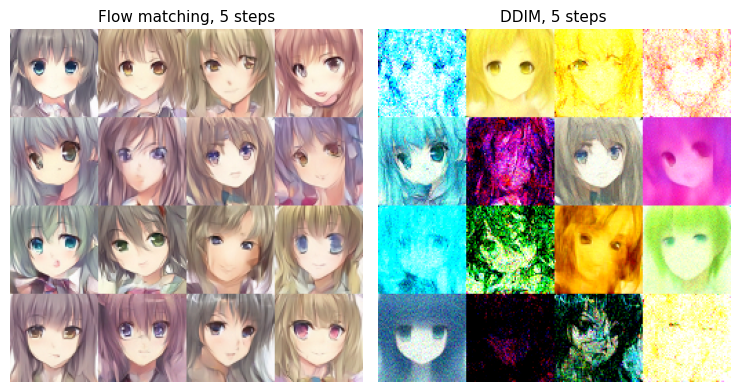

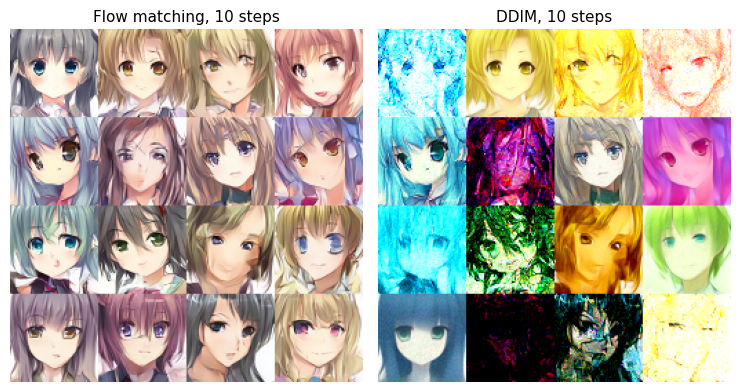

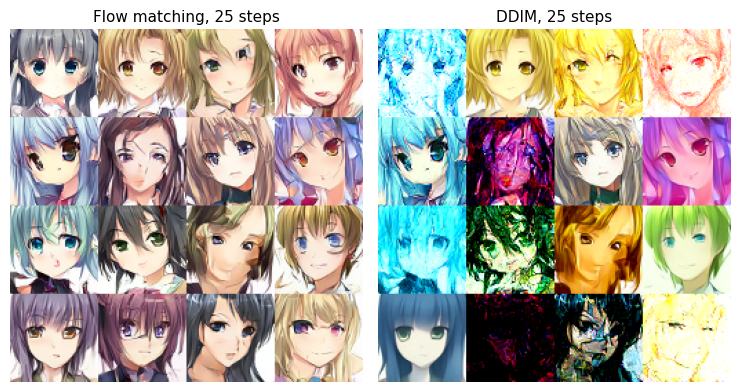

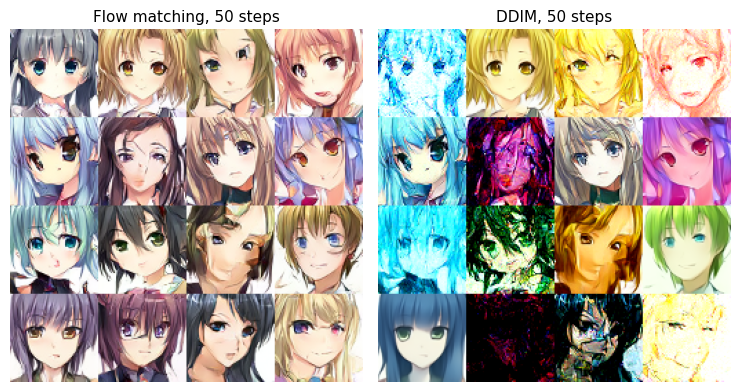

In [22]:
# Head to head at MATCHED step counts -- the fair comparison
for s in [5, 10, 25, 50]:
    plt.figure(figsize=(7.5, 4))
    torch.manual_seed(7); plt.subplot(1,2,1); show(fm_sample(ema, 16, steps=s),   f'Flow matching, {s} steps')
    torch.manual_seed(7); plt.subplot(1,2,2); show(ddim_sample(ema_d, 16, steps=s), f'DDIM, {s} steps')
    plt.tight_layout(); plt.show()

---
## 9. Summary — what to remember

**The method, in full:**

$$x_t = (1-t)x_0 + t x_1 \qquad v_{\text{target}} = x_1 - x_0 \qquad \mathcal{L} = \|v_\theta(x_t,t) - v_{\text{target}}\|^2 \qquad \text{sample: } x \mathrel{+}= v_\theta(x,t)\,dt$$

Four expressions. No schedule, no $\bar\alpha$ table, no posterior variance, no reweighting.

**Where it sits in the family:**
- FM **is** in the diffusion family — we showed $v$ and $\epsilon$ are exact linear reparameterizations of each other (§3).
- "FM is the ODE version of diffusion" is **half true**: DDIM is already a deterministic ODE. The real difference is that FM's path is a **straight line** ($a+b=1$) where DDPM's is a **circular arc** ($a^2+b^2=1$).
- Straight path → nearly constant velocity → large Euler steps don't overshoot → **~10 steps instead of ~1000**.

**What's honest about the "better" claim:**
- ✅ Far fewer steps than DDPM's stochastic sampler (10 vs 1000).
- ✅ No schedule to tune; uniform loss weighting; works for arbitrary source distributions (why SD3/Flux use it).
- ⚠️ vs **DDIM at matched steps**, the win is modest — both are ODEs.
- ❌ **Not** one-step. That's reflow or distillation, layered on top.

**Latent FM:** change `x1 = images` to `x1 = vae.encode(images).latents`, decode at the end. Nothing else changes — FM doesn't care what space it interpolates in.

**Further:** Lipman et al., *Flow Matching for Generative Modeling* (2210.02747) · Liu et al., *Rectified Flow* (2209.03003) · Esser et al., *SD3* (2403.03206)